In [2]:
library(igraph)
library(ggplot2)
library(RColorBrewer)
library(rgl)

source("common.R")

mypal = colorRampPalette(rev(c(brewer.pal(9, "YlGnBu"))))(20)

# City Data

In [3]:
node_info <- read.csv("city_undir_nodes.csv", header=T)
head(node_info)

,osmid,y,x,highway,street_count,lon,lat,elevation,ref,geometry
,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,141540485,5034217,724692.1,crossing,4,11.87222,45.42536,11.017,,POINT (724692.0524323853 5034217.2220378015)
2,254672751,5034215,724686.9,,3,11.87215,45.42534,11.044,,POINT (724686.9151817659 5034214.78035585)
3,197522982,5034188,724705.4,,3,11.87237,45.42509,11.109,,POINT (724705.4056372979 5034188.344207406)
4,254672878,5034235,724685.3,,3,11.87214,45.42551,11.045,,POINT (724685.3487468463 5034234.502062533)
5,2522360915,5034220,724699.5,,3,11.87231,45.42538,11.277,,POINT (724699.5259766739 5034220.4813790545)
6,2522360901,5034168,724711.1,crossing,4,11.87244,45.42490,11.353,,POINT (724711.0918296422 5034167.757504167)


In [4]:
edge_info <- read.csv("city_undir_edges.csv", header=T)
head(edge_info)

,u,v,key,osmid,highway,oneway,length,geometry,grade,grade_abs,⋯,width,maxspeed,tunnel,ref,bridge,junction,est_width,access,service,area
,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,141540485,254672751,0,23516562,path,False,5.674,"LINESTRING (724686.9151817659 5034214.78035585, 724692.0524323853 5034217.2220378015)",-0.005,0.005,⋯,,,,,,,,,,
2,141540485,197522982,0,41224006,tertiary,False,31.809,"LINESTRING (724705.4056372979 5034188.344207406, 724692.0524323853 5034217.2220378015)",-0.003,0.003,⋯,,,,,,,,,,
3,141540485,254672878,0,41224006,tertiary,False,18.533,"LINESTRING (724685.3487468463 5034234.502062533, 724692.0524323853 5034217.2220378015)",-0.002,0.002,⋯,,,,,,,,,,
4,141540485,2522360915,0,244968997,path,False,8.132,"LINESTRING (724699.5259766739 5034220.4813790545, 724692.0524323853 5034217.2220378015)",-0.032,0.032,⋯,,,,,,,,,,
5,254672751,2522360901,0,244968982,path,False,52.914,"LINESTRING (724711.0918296422 5034167.757504167, 724700.0982905193 5034186.497108992, 724686.9151817659 5034214.78035585)",-0.006,0.006,⋯,3,,,,,,,,,
6,254672751,1706766353,0,244968982,path,False,74.032,"LINESTRING (724666.1489702093 5034285.395859767, 724668.4031417936 5034268.346135213, 724673.2813136817 5034248.008621904, 724679.828307144 5034231.824219752, 724686.9151817659 5034214.78035585)",-0.006,0.006,⋯,3,,,,,,,,,


In [9]:
nodes <- node_info[,c("osmid", "lat", "lon")]
edges <- data.frame(from=edge_info$u, to=edge_info$v)

g <- graph_from_data_frame(edges, directed=F, vertices=as.character(nodes$osmid))
g <- simplify(g) # remove self loops and multiple edges
g

IGRAPH 7fbab57 UN-- 21074 29205 -- 
+ attr: name (v/c)
+ edges from 7fbab57 (vertex names):
 [1] 141540485 --254672751  141540485 --197522982  141540485 --254672878 
 [4] 141540485 --2522360915 254672751 --2522360901 254672751 --1706766353
 [7] 197522982 --251308762  197522982 --2522360911 254672878 --2522360919
[10] 254672878 --2796391751 2522360915--2522360919 2522360915--2522360913
[13] 2522360901--251308762  2522360901--2522360896 2522360901--251308761 
[16] 1706766353--2796391754 1706766353--2796391752 251308762 --251308760 
[19] 2522360911--2522360913 2522360911--243487238  2522360911--2522360880
[22] 2522360919--2522409502 2522360919--2522360929 2796391751--2796391752
+ ... omitted several edges

we want to use the coordinates to plot the city 

In [11]:
layout <- matrix(0, vcount(g), 2)
layout[,1] <- nodes$lon
layout[,2] <- nodes$lat

v_cent <- closeness(g, normalize=F) 
# closeness is a way to understand topologically how much a node is close to another node

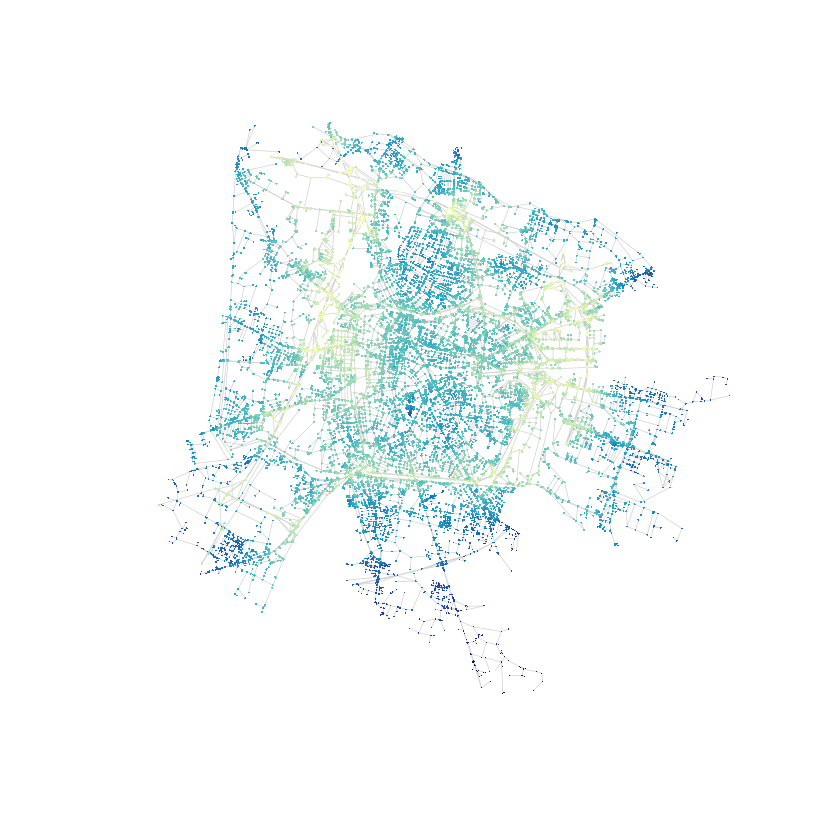

In [14]:
colors <- vec2pal(v_cent, mypal)
sizes <- v_cent/max(v_cent)

plot(g, layout=layout, vertex.label=NA, vertex.color=colors, vertex.frame.color=NA, vertex.size=sizes, edge.color="gray80", edge.width=0.5)